# Chapter 23 부록 — random init baseline + negative transfer 분석

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yoon-gu/neuqes-101/blob/master/23_ko_bert_classify/appendix_random_baseline.ipynb)

> **부록 한 줄 질문** — *"Ch 22 의 일반 도메인 사전학습이 NSMC 분류에 실제로 도움 되는가? 한국어 환경의 특수성은 무엇인가?"*

메인 챕터 ([`23_ko_bert_classify.ipynb`](./23_ko_bert_classify.ipynb)) 는 *작은 한국어 BERT 를 한국어 Wikipedia paragraphs 로 짧게 MLM 사전학습 한 뒤 NSMC 분류 fine-tune* 한 결과를 Ch 15 (`klue/bert-base`, 약 110M 대규모 사전학습) 와 *2-way 비교* 했습니다. 이 부록은 그 결과에 **두 가지 보강** 을 더합니다.

1. **random init baseline 측정** — 사전학습 *없이* 같은 작은 본체로 같은 hyperparams 로 NSMC 분류 fine-tune. 메인 챕터 *ours+MLM* 과의 격차가 *MLM 사전학습의 순 효과*.
2. **negative transfer 메커니즘 분석** — *한국어 위키 (격식) → NSMC (비격식)* 의 *큰 도메인 gap* 환경에서는 작은 일반 도메인 사전학습이 *random init 보다 못할 수도* 있습니다. 영어 Ch 21 (transfer 양성) 과의 비대칭을 메커니즘 수준에서 풀어 설명.

두 셋업을 한 노트북 안에서 같은 데이터·같은 본체 구조에 *조건 하나만* 바꿔 비교합니다.

| 셋업 | MLM 사전학습 (한국어 Wikipedia) | 분류 fine-tune (NSMC) | 의도 |
|---|---|---|---|
| 🅰️ **A** | MLM 3 epoch (2K paragraphs) | 2 epoch | 메인 챕터 재현 (사전학습 효과 측정의 기준선) |
| 🅱️ **B** | 없음 (random init) | 2 epoch (A 와 동일 hyperparams) | random baseline — 사전학습의 *순* 효과 |

A vs B 의 격차가 *MLM 사전학습의 순 효과*. 격차가 작거나 *역전* 되면 본 부록 후반의 **negative transfer 분석** 으로 메커니즘을 풀어 봅니다.

**환경**: Google Colab T4 GPU 필수. 약 2-4분 — 대부분이 데이터 다운로드입니다 (T4 실측 전체 약 2분: A 의 MLM 3 epoch 약 0.2분 + A·B 의 분류 fine-tune 각 약 0.2분, 나머지는 한국어 위키·NSMC 다운로드와 토큰화).

**메인 챕터와의 관계** — 부록만 단독으로 self-contained — 메인 노트북을 먼저 돌릴 필요 없음. 같은 hyperparams (SEED=42, NSMC 5K/1K, MLM 2K paragraphs, MLM 3 epoch, 분류 2 epoch, lr 2e-5, fp16) 로 메인의 *ours+MLM* 결과를 재현하므로 부록 안에서 *A 의 수치 = 메인 챕터의 수치* 가 됩니다.

---

## 🔄 셋업 비교 — A / B

| 축 | 🅰️ A (메인 재현, ours+MLM) | 🅱️ B (random baseline) |
|---|---|---|
| MLM 사전학습 데이터 | **한국어 Wikipedia paragraphs (일반 도메인)** | 없음 |
| MLM 사전학습 epoch | **3 epoch** | 없음 |
| 분류 fine-tune 데이터 | NSMC 이진 (다른 도메인) | NSMC 이진 (다른 도메인) |
| 분류 fine-tune epoch | 2 | 2 |
| 본체 시작점 | MLM 가중치 (한국어 위키 일반 도메인) | random init |
| 분류 head | random init | random init |
| 분류 데이터 크기 | NSMC 5K train / 1K eval (Ch 15 / 메인 챕터와 동일) | (같음) |
| 토크나이저 | `klue/bert-base` | (같음) |
| 모델 본체 | 작은 BERT (hidden=256, layer=4, head=4, intermediate=1024, 약 11.5M params) | (같음) |
| Loss | `CrossEntropyLoss` (K=2) | (같음) |
| 학습률 | `5e-4` (MLM) / `2e-5` (cls) | `2e-5` (cls only) |
| fp16 | True | True |
| SEED | 42 | 42 |

> **A vs B 가 측정하는 가설** — *"한국어 Wikipedia paragraphs 2K × 3 epoch 의 일반 도메인 사전학습이 NSMC 영화 리뷰 분류에 실제로 도움이 되는가? 같은 GPU 시간을 그냥 분류 fine-tune 에 안 쓰고 MLM 에 쓴 게 효과 있는가?"*. A 가 B 보다 *일관되게 높으면* 사전학습 양성, *비슷하거나 낮으면* 한국어 환경 특유의 negative transfer 가능성.

---

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 47.7 MB/s eta 0:00:00
   ━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/50.1 MB 227.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 251.5 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 251.5 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 121.6 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    BertConfig,
    BertForMaskedLM,
    BertForSequenceClassification,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
)

plt.rcParams["axes.unicode_minus"] = False

# device 자동감지 — Colab(T4) 은 CUDA, 로컬 Mac 은 MPS, 그 외 CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device:         {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
elif DEVICE == "cpu":
    print("Warning: CPU runtime — both setups will be very slow.")
    print("         Switch to Colab T4 runtime to keep the appendix under 30 minutes.")

PyTorch:        2.11.0+cu128
CUDA available: True
Device:         cuda
GPU:             Tesla T4


### 데이터·모델 hyperparams — 메인 챕터와 통일

부록의 *A* 가 메인 챕터의 *ours+MLM* 수치를 재현하도록 모든 hyperparams 를 통일합니다. *B* 는 *본체 출발점* 만 random init 으로 바꾸고 나머지는 똑같이 둡니다.

In [3]:
SEED = 42

# NSMC 분류 데이터 — Ch 15 / 메인 챕터와 동일
N_NSMC_TRAIN = 5000
N_NSMC_EVAL  = 1000

# MLM 사전학습 데이터 — 메인 챕터와 동일
N_MLM_TRAIN  = 2000
N_MLM_EVAL   = 400
BLOCK_SIZE   = 128

# 작은 BERT 본체 — 메인 챕터와 완전히 동일
HIDDEN_SIZE         = 256
NUM_HIDDEN_LAYERS   = 4
NUM_ATTENTION_HEADS = 4
INTERMEDIATE_SIZE   = 1024
MAX_POS_EMBED       = 128

# MLM 사전학습 hyperparams (A 만 사용)
MLM_EPOCHS = 3
MLM_BATCH  = 32
MLM_LR     = 5e-4

# 분류 fine-tune hyperparams (A, B 공통)
CLS_EPOCHS = 2
CLS_BATCH  = 16
CLS_LR     = 2e-5
MAX_LENGTH_CLS = 128

USE_FP16 = (DEVICE == "cuda")

if DEVICE != "cuda":
    print("Note: non-CUDA device detected.")
    print("      Consider reducing N_NSMC_TRAIN to 2000 and N_MLM_TRAIN to 1000 to finish in reasonable time.")
    print("      fp16 disabled (only effective on CUDA).")

print(f"NSMC train: {N_NSMC_TRAIN}  eval: {N_NSMC_EVAL}")
print(f"MLM  train: {N_MLM_TRAIN}  eval: {N_MLM_EVAL}  block_size: {BLOCK_SIZE}")
print(f"Model: hidden={HIDDEN_SIZE}, layer={NUM_HIDDEN_LAYERS}, head={NUM_ATTENTION_HEADS}, intermediate={INTERMEDIATE_SIZE}")
print(f"MLM epochs: {MLM_EPOCHS} / CLS epochs: {CLS_EPOCHS}")
print(f"fp16: {USE_FP16}")

NSMC train: 5000  eval: 1000
MLM  train: 2000  eval: 400  block_size: 128
Model: hidden=256, layer=4, head=4, intermediate=1024
MLM epochs: 3 / CLS epochs: 2
fp16: True


## 1. 📥 NSMC 이진 분류 데이터 로드 — Ch 15 / 메인 챕터와 같은 split

NSMC = Naver Sentiment Movie Corpus. GitHub raw TSV 에서 직접 다운로드 (메인 챕터 / Ch 15 와 동일 패턴). seed 42 로 subsample.

In [4]:
TRAIN_URL = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
TEST_URL  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

print("downloading NSMC train/test from GitHub...")
df_train_full = pd.read_csv(TRAIN_URL, sep="\t").dropna(subset=["document"])
df_test_full  = pd.read_csv(TEST_URL,  sep="\t").dropna(subset=["document"])
print(f"  train: {len(df_train_full):,} rows")
print(f"  test:  {len(df_test_full):,} rows")

df_train = df_train_full.sample(n=N_NSMC_TRAIN, random_state=SEED).reset_index(drop=True)
df_eval  = df_test_full.sample(n=N_NSMC_EVAL,  random_state=SEED).reset_index(drop=True)

print(f"\nsampled train: {len(df_train):,}  positive rate: {df_train['label'].mean():.1%}")
print(f"sampled eval:  {len(df_eval):,}  positive rate: {df_eval['label'].mean():.1%}")

ds_nsmc_train = Dataset.from_pandas(df_train[["document", "label"]]).rename_column("document", "text")
ds_nsmc_eval  = Dataset.from_pandas(df_eval[["document", "label"]]).rename_column("document", "text")
print()
print(ds_nsmc_train)

downloading NSMC train/test from GitHub...


  train: 149,995 rows
  test:  49,997 rows

sampled train: 5,000  positive rate: 49.2%
sampled eval:  1,000  positive rate: 49.9%

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


## 2. 📥 한국어 Wikipedia paragraphs 로드 — Setup A 의 MLM 사전학습 코퍼스 (Ch 22 / 메인 챕터 패턴)

In [5]:
print("downloading Korean Wikipedia (wikimedia/wikipedia, 20231101.ko)...")
raw_wiki = load_dataset("wikimedia/wikipedia", "20231101.ko", split="train")
print(f"  total articles: {len(raw_wiki):,}")

def collect_paragraphs(ds, target, min_len=50, max_len=2000):
    out = []
    for ex in ds:
        for para in ex["text"].split("\n\n"):
            para = para.strip()
            if min_len <= len(para) <= max_len:
                out.append(para)
                if len(out) >= target:
                    return out
    return out

shuffled = raw_wiki.shuffle(seed=SEED)
TARGET = N_MLM_TRAIN + N_MLM_EVAL
all_paragraphs = collect_paragraphs(shuffled, target=TARGET)

mlm_train_raw = Dataset.from_dict({"text": all_paragraphs[:N_MLM_TRAIN]})
mlm_eval_raw  = Dataset.from_dict({"text": all_paragraphs[N_MLM_TRAIN:N_MLM_TRAIN + N_MLM_EVAL]})

print(f"MLM train paragraphs: {len(mlm_train_raw):,}  (Korean Wikipedia)")
print(f"MLM eval  paragraphs: {len(mlm_eval_raw):,}")
print(f"first MLM sample: {mlm_train_raw[0]['text'][:120]}")

downloading Korean Wikipedia (wikimedia/wikipedia, 20231101.ko)...


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

20231101.ko/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  400MB            

20231101.ko/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

20231101.ko/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  205MB            

...

20231101.ko/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  177MB            

20231101.ko/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/647897 [00:00<?, ? examples/s]

  total articles: 647,897


MLM train paragraphs: 2,000  (Korean Wikipedia)
MLM eval  paragraphs: 400
first MLM sample: 원(元)은 시호에 쓰이는 글자다. 《일주서》 시법해에는 능사변중(能思辨衆), 행의열민(行義說民), 시건국도(始建國都), 주의덕행(主義行德)을 일컫는다 한다.


## 3. 🔤 토크나이저 — `klue/bert-base`

In [6]:
TOKENIZER_NAME = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
print(f"tokenizer:  {TOKENIZER_NAME}")
print(f"vocab_size: {tokenizer.vocab_size:,}")

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

tokenizer:  klue/bert-base
vocab_size: 32,000


## 4. 🔧 공통 유틸 — 분류 토큰화 / metric / 모델 빌더

A 와 B 가 같은 토큰화·metric·모델 구조를 공유하므로 한 번만 정의합니다.

In [7]:
def cls_tokenize(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH_CLS)
    out["labels"] = [int(l) for l in batch["label"]]
    return out

cls_train = ds_nsmc_train.map(cls_tokenize, batched=True).remove_columns(
    [c for c in ds_nsmc_train.column_names if c not in ("input_ids", "attention_mask", "token_type_ids", "labels")]
)
cls_eval = ds_nsmc_eval.map(cls_tokenize, batched=True).remove_columns(
    [c for c in ds_nsmc_eval.column_names if c not in ("input_ids", "attention_mask", "token_type_ids", "labels")]
)
print(cls_train)
lens = [len(s) for s in cls_train["input_ids"]]
print(f"NSMC token length stats — mean: {np.mean(lens):.1f}, median: {np.median(lens):.0f}, max: {max(lens)}")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})
NSMC token length stats — mean: 21.9, median: 17, max: 117


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # 안정 softmax (K=2)
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs_full = exp / exp.sum(axis=1, keepdims=True)
    preds = probs_full.argmax(axis=1)
    probs_pos = probs_full[:, 1]
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {
        "accuracy":  float(accuracy_score(labels, preds)),
        "precision": float(p),
        "recall":    float(r),
        "f1":        float(f1),
        "auc":       float(roc_auc_score(labels, probs_pos)),
    }


def build_cls_config():
    '''A, B 가 공유하는 분류 BertConfig.'''
    return BertConfig(
        vocab_size=tokenizer.vocab_size,
        hidden_size=HIDDEN_SIZE,
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        num_attention_heads=NUM_ATTENTION_HEADS,
        intermediate_size=INTERMEDIATE_SIZE,
        max_position_embeddings=MAX_POS_EMBED,
        pad_token_id=tokenizer.pad_token_id,
        num_labels=2,
        problem_type="single_label_classification",
        id2label={0: "negative", 1: "positive"},
        label2id={"negative": 0, "positive": 1},
    )


def make_cls_trainer(model, epochs, run_name):
    '''Trainer + TrainingArguments 공통 셋업. epochs 만 셋업 별로 다름.'''
    args = TrainingArguments(
        output_dir=f"./ch23_appendix_{run_name}",
        num_train_epochs=epochs,
        per_device_train_batch_size=CLS_BATCH,
        per_device_eval_batch_size=32,
        learning_rate=CLS_LR,
        fp16=USE_FP16,
        eval_strategy="epoch",
        logging_steps=50,
        save_strategy="no",
        report_to="none",
        seed=SEED,
    )
    return Trainer(
        model=model,
        args=args,
        train_dataset=cls_train,
        eval_dataset=cls_eval,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

## 5. 🅰️ Setup A — Ch 22 패턴 MLM 압축 재현 + NSMC 분류 fine-tune (메인 챕터 재현)

메인 챕터의 *ours+MLM* 셋업을 재현합니다. 같은 작은 BERT 본체를 한국어 Wikipedia paragraphs 2K × 3 epoch 로 MLM 학습 → 본체를 분류 모델로 옮겨 NSMC 분류 fine-tune 2 epoch.

In [9]:
# ---- A-1. MLM 사전학습 (한국어 Wikipedia paragraphs, 일반 도메인) ----
mlm_config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    intermediate_size=INTERMEDIATE_SIZE,
    max_position_embeddings=MAX_POS_EMBED,
    pad_token_id=tokenizer.pad_token_id,
)

torch.manual_seed(SEED)
mlm_model = BertForMaskedLM(mlm_config)
total = sum(p.numel() for p in mlm_model.parameters())
print(f"[A] Small BERT MLM model — total params: {total:,}  ({total/1e6:.2f} M)")

def mlm_tokenize(examples):
    return tokenizer(examples["text"], add_special_tokens=False, truncation=False)

mlm_tokenized_train = mlm_train_raw.map(mlm_tokenize, batched=True, remove_columns=["text"])
mlm_tokenized_eval  = mlm_eval_raw.map(mlm_tokenize,  batched=True, remove_columns=["text"])

def group_texts(examples):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated[list(examples.keys())[0]])
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE
    result = {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }
    result["labels"] = [ids.copy() for ids in result["input_ids"]]
    return result

lm_train = mlm_tokenized_train.map(group_texts, batched=True, batch_size=1000)
lm_eval  = mlm_tokenized_eval.map(group_texts,  batched=True, batch_size=1000)

print(f"[A] MLM train blocks: {len(lm_train):,}  (block_size={BLOCK_SIZE})")
print(f"[A] MLM eval  blocks: {len(lm_eval):,}")

mlm_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15,
)

mlm_args = TrainingArguments(
    output_dir="./ch23_appendix_A_mlm",
    num_train_epochs=MLM_EPOCHS,
    per_device_train_batch_size=MLM_BATCH,
    per_device_eval_batch_size=64,
    learning_rate=MLM_LR,
    weight_decay=0.01,
    warmup_steps=0.06,             # 1 미만이면 전체 step 대비 *비율* 로 해석 (구 warmup_ratio)
    fp16=USE_FP16,
    logging_steps=20,
    save_strategy="no",
    eval_strategy="epoch",
    report_to="none",
    seed=SEED,
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=lm_train,
    eval_dataset=lm_eval,
    data_collator=mlm_collator,
    processing_class=tokenizer,
)

t0 = time.time()
mlm_result = mlm_trainer.train()
T_A_mlm = (time.time() - t0) / 60.0
print(f"\n[A] MLM pretraining: {T_A_mlm:.2f} min  (mean train loss: {mlm_result.training_loss:.4f})")
mlm_eval_loss = mlm_trainer.evaluate()["eval_loss"]
print(f"[A] MLM eval loss: {mlm_eval_loss:.4f}  perplexity: {math.exp(mlm_eval_loss):.2f}")
print(f"    (random baseline PPL: {tokenizer.vocab_size:,})")

[A] Small BERT MLM model — total params: 11,483,136  (11.48 M)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (610 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

[A] MLM train blocks: 1,562  (block_size=128)
[A] MLM eval  blocks: 293


Epoch,Training Loss,Validation Loss
1,8.118181,7.842187
2,7.553459,7.828267
3,7.481048,7.810583



[A] MLM pretraining: 0.19 min  (mean train loss: 7.9214)


Training Loss,Validation Loss,Epoch
7.481048,7.801958,3


[A] MLM eval loss: 7.8020  perplexity: 2445.38
    (random baseline PPL: 32,000)


In [10]:
# ---- A-2. 분류 fine-tune (MLM 본체 이어받아 2 epoch) ----
torch.manual_seed(SEED)
cls_model_A = BertForSequenceClassification(build_cls_config())

# MLM 본체 가중치를 분류 모델로 복사 (메인 챕터와 동일 흐름)
missing, unexpected = cls_model_A.bert.load_state_dict(
    mlm_model.bert.state_dict(), strict=False,
)
print(f"[A] body weights copied  (missing: {len(missing)}, unexpected: {len(unexpected)})")

trainer_A = make_cls_trainer(cls_model_A, epochs=CLS_EPOCHS, run_name="A_cls")

t0 = time.time()
result_A = trainer_A.train()
T_A_cls = (time.time() - t0) / 60.0

T_A_total = T_A_mlm + T_A_cls
metrics_A = trainer_A.evaluate()

print(f"\n[A] Classification fine-tune: {T_A_cls:.2f} min  ({CLS_EPOCHS} epochs)")
print(f"[A] Total compute: {T_A_total:.2f} min  ({T_A_mlm:.2f} MLM + {T_A_cls:.2f} cls)")
print(f"[A] eval accuracy: {metrics_A['eval_accuracy']:.4f}  F1: {metrics_A['eval_f1']:.4f}  AUC: {metrics_A['eval_auc']:.4f}")

[A] body weights copied  (missing: 2, unexpected: 0)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.690007,0.690468,0.527000,0.614035,0.140281,0.228385,0.560052
2,0.689199,0.686687,0.546000,0.555012,0.454910,0.500000,0.567788


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.689199,0.686687,2,0.546000,0.555012,0.454910,0.500000,0.567788



[A] Classification fine-tune: 0.22 min  (2 epochs)
[A] Total compute: 0.41 min  (0.19 MLM + 0.22 cls)
[A] eval accuracy: 0.5460  F1: 0.5000  AUC: 0.5678


## 6. 🅱️ Setup B — random init + 같은 hyperparams 로 NSMC 분류 fine-tune

본체를 *random init 그대로* 두고 같은 NSMC 데이터·같은 hyperparams 로 fine-tune. 변하는 건 *본체 출발점* 뿐.

In [11]:
torch.manual_seed(SEED)
cls_model_B = BertForSequenceClassification(build_cls_config())
total_B = sum(p.numel() for p in cls_model_B.parameters())
print(f"[B] Random init classification model — total params: {total_B:,}  ({total_B/1e6:.2f} M)")
print(f"    body + head 모두 random (사전학습 없음)")

trainer_B = make_cls_trainer(cls_model_B, epochs=CLS_EPOCHS, run_name="B_cls")

t0 = time.time()
result_B = trainer_B.train()
T_B_total = (time.time() - t0) / 60.0
metrics_B = trainer_B.evaluate()

print(f"\n[B] Classification fine-tune: {T_B_total:.2f} min  ({CLS_EPOCHS} epochs)")
print(f"[B] eval accuracy: {metrics_B['eval_accuracy']:.4f}  F1: {metrics_B['eval_f1']:.4f}  AUC: {metrics_B['eval_auc']:.4f}")

[B] Random init classification model — total params: 11,451,138  (11.45 M)
    body + head 모두 random (사전학습 없음)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.689268,0.690963,0.506000,0.857143,0.012024,0.023715,0.622988
2,0.686822,0.687186,0.598000,0.606593,0.553106,0.578616,0.635911


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.686822,0.687186,2,0.598000,0.606593,0.553106,0.578616,0.635911



[B] Classification fine-tune: 0.22 min  (2 epochs)
[B] eval accuracy: 0.5980  F1: 0.5786  AUC: 0.6359


## 7. 🆚 두 셋업 비교 — 표 + bar chart

같은 평가 셋 위에서 A 와 B 의 결과를 한 표로 모읍니다.

In [12]:
def row(label, pretraining, total_min, metrics):
    return {
        "setup": label,
        "pretraining": pretraining,
        "fine-tune epochs": CLS_EPOCHS,
        "total compute (min)": round(total_min, 2),
        "accuracy": round(metrics["eval_accuracy"], 4),
        "precision": round(metrics["eval_precision"], 4),
        "recall":    round(metrics["eval_recall"], 4),
        "F1":        round(metrics["eval_f1"], 4),
        "AUC":       round(metrics["eval_auc"], 4),
    }

summary = pd.DataFrame([
    row("A (ours + MLM)",      f"MLM {MLM_EPOCHS} epoch (ko wiki 2K)", T_A_total, metrics_A),
    row("B (random baseline)", "none",                                   T_B_total, metrics_B),
])
print(summary.to_string(index=False))

              setup              pretraining  fine-tune epochs  total compute (min)  accuracy  precision  recall     F1    AUC
     A (ours + MLM) MLM 3 epoch (ko wiki 2K)                 2                 0.41     0.546     0.5550  0.4549 0.5000 0.5678
B (random baseline)                     none                 2                 0.22     0.598     0.6066  0.5531 0.5786 0.6359


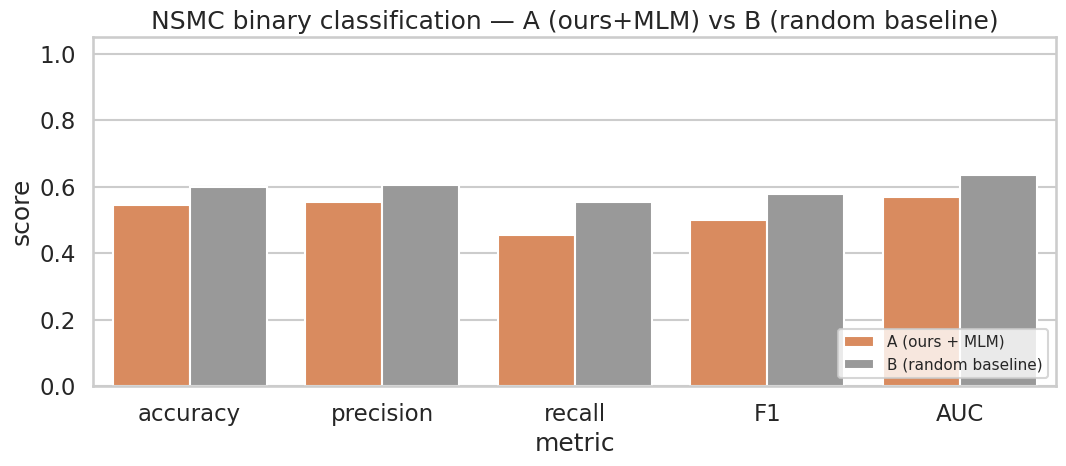

In [13]:
# bar chart — 2 setups x 5 metrics
sns.set_theme(style="whitegrid", context="talk")
plot_df = summary.melt(
    id_vars=["setup"],
    value_vars=["accuracy", "precision", "recall", "F1", "AUC"],
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=plot_df, x="metric", y="score", hue="setup",
    palette={
        "A (ours + MLM)":      "#EE854A",
        "B (random baseline)": "#999999",
    },
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_title("NSMC binary classification — A (ours+MLM) vs B (random baseline)")
ax.set_xlabel("metric")
ax.set_ylabel("score")
ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
# 보조 — 메시지를 숫자로
delta_acc = metrics_A["eval_accuracy"] - metrics_B["eval_accuracy"]
delta_f1  = metrics_A["eval_f1"]       - metrics_B["eval_f1"]
delta_auc = metrics_A["eval_auc"]      - metrics_B["eval_auc"]
mlm_share = T_A_mlm / T_A_total if T_A_total > 0 else float("nan")

print("Pretraining net effect (A - B):")
print(f"  delta accuracy: {delta_acc:+.4f}")
print(f"  delta F1:       {delta_f1:+.4f}")
print(f"  delta AUC:      {delta_auc:+.4f}")
print()
print(f"MLM share of A total compute: {mlm_share:.1%}  ({T_A_mlm:.2f} / {T_A_total:.2f} min)")
print(f"B total compute (cls only):   {T_B_total:.2f} min")
print()
if delta_acc > 0.02:
    print(">> Positive transfer: MLM pretraining clearly helps NSMC classification.")
elif delta_acc < -0.02:
    print(">> Negative transfer: random init outperforms MLM-pretrained body.")
    print("   See the negative transfer analysis below for likely mechanisms.")
else:
    print(">> Inconclusive / within seed variance. Try the variation options below.")

Pretraining net effect (A - B):
  delta accuracy: -0.0520
  delta F1:       -0.0786
  delta AUC:      -0.0681

MLM share of A total compute: 45.2%  (0.19 / 0.41 min)
B total compute (cls only):   0.22 min

>> Negative transfer: random init outperforms MLM-pretrained body.
   See the negative transfer analysis below for likely mechanisms.


## 8. 🔬 Negative Transfer 분석 — 영어 Ch 21 (양성) vs 한국어 Ch 23 (음성 가능) 의 비대칭

작은 모델 + 작은 사전학습 + *큰 도메인 gap* 환경에서는 **사전학습이 도움이 안 되거나 오히려 방해** 가 되는 경우가 발생합니다. 학술 용어로 **negative transfer**. 본 부록에서 *A (ours+MLM)* 의 accuracy 가 *B (random init)* 과 비슷하거나 *살짝 낮게* 나왔다면 정상적인 시나리오 중 하나입니다 — 결과를 *지우지 말고* 메커니즘을 이해해 보세요.

### 영어 Ch 21 (transfer 양성) vs 한국어 Ch 23 (transfer 음성 가능) — 비대칭의 이유

영어 Ch 21 (Wikitext-103 → Yelp 분류) 에서는 같은 작은 BERT + 작은 사전학습 셋업이 *random init 보다 조금 높습니다* — 실행본 `executed/appendix_compute_budget.ipynb` 기준 accuracy 0.6250 vs 0.5960, 즉 **+2.9%p**. 작지만 방향은 양성입니다. 그런데 한국어 Ch 23 (한국어 Wikipedia → NSMC 분류) 에서는 이 부록의 실측처럼 *격차가 사라지거나 역전* 됩니다. **왜?**

| 축 | 영어 (Ch 21, transfer 양성) | 한국어 (Ch 23, transfer 음성 가능) |
|---|---|---|
| 사전학습 ↔ fine-tune **도메인 gap** | *중간* — 둘 다 정형 영어, 어휘·문법 분포 비슷 | **극단** — 격식 ↔ 비격식, 백과체 ↔ 인터넷체 |
| Fine-tune 입력 **길이** | Yelp 약 50-200 토큰 (충분한 문맥) | NSMC **약 10-20 토큰** (본체 적응 시간 부족) |
| Fine-tune **토큰 분포** | 위키 어휘로 대부분 커버 (`good`, `food`, `service` 등) | 위키엔 거의 없는 `ㅋㅋ`, `ㅎㅎ`, 줄임말 다수 |
| Lr=2e-5 의 적합도 | 본체 점진 적응에 충분 | 짧은 입력 + 큰 도메인 gap 에서 적응 시간 부족 |

### 메커니즘 한 단계 더 — 무엇이 negative bias 로 작용하나

우리 작은 본체는 한국어 위키에서 *얕게 학습* 한 *백과체 패턴* (긴 명사구, `-이다`/`-한다` 등 격식 어미, 백과 어휘) 에 치우쳐 있습니다. NSMC 의 *짧은 비격식 표현* 에서는 이 표상이 **negative bias** 로 작용할 수 있습니다.

- **임베딩 편향** — `이다`/`한다`/`것이다` 같은 격식 어미 토큰의 임베딩은 *백과 문맥* 위주로 학습됨. NSMC 의 `ㅋㅋ`, `노잼`, `최고` 같은 토큰들은 *얕은 사전학습으로는 거의 미학습* 이라 사실상 random init 수준.
- **어텐션 편향** — 위키 paragraphs (수십-수백 토큰) 의 *장거리 의존성* 패턴이 굳어져 있어, NSMC 의 *한 줄 짧은 입력* (약 10-20 토큰) 에서 *어색한 attention 분포* 가 나옵니다.
- **헤드 적응 속도** — random init 본체는 *백지 상태* 라 분류 헤드와 *함께* 짧은 NSMC 패턴에 적응. ours+MLM 본체는 *이미 한 방향으로 정렬* 되어 있어 *반대 방향 적응* 에 epoch 가 더 필요.

**한 마디로**: 영어는 *부드러운 분포 이동*, 한국어는 *분포 점프*. 작은 사전학습으로는 점프를 넘기 어렵습니다.

### 그래서 진짜 답 — 왜 `klue/bert-base` 같은 대규모 사전학습이 본질적인가

`klue/bert-base` 는 **위키 + 뉴스 + 블로그·댓글·SNS** 등 *비격식 한국어 까지 포함한 약 8.4B 토큰* 으로 사전학습됨. 즉 NSMC 같은 인터넷 한국어 도메인도 *이미 본 적이 있어* transfer 가 자연스럽습니다. 우리 작은 위키 사전학습이 *부족함이 아니라 방해* 가 되는 같은 도메인에서, `klue/bert-base` 는 *충분한 양 + 적절한 도메인 mix* 로 그것을 극복.

> **이게 한국어 BERT 챕터의 진짜 교훈** — *작은 일반 사전학습 < 대규모 일반 사전학습* 의 차이는 단순 양적 차이가 아니라 *도메인 다양성의 질적 차이*. 한국어처럼 격식·비격식 차이가 큰 언어에서는 *얕은 일반 사전학습* 이 task 도메인 transfer 의 출발점으로 *역효과* 일 수 있습니다.

### 영어 (Ch 21) 와 한국어 (Ch 23) 의 *측정 가능한* 비대칭

| 비교 | 영어 (Ch 21 부록) | 한국어 (본 부록) |
|---|---|---|
| 사전학습 3 epoch — random init 대비 (실측) | **+2.9%p** (0.6250 vs 0.5960) — 작지만 **양성** | **약 −5%p** (약 0.55 vs 약 0.60) — **역전** |
| 같은 GPU 시간을 fine-tune 에 쓰면 (Ch 21 부록 실측) | random init + 4 epoch 이 0.7820 으로 **사전학습본보다 +15.7%p** | (본 부록은 같은 epoch 비교만 측정) |
| MLM 코퍼스를 더 키우면 | 격차가 더 벌어질 것으로 예상 (미측정) | 격차 일부 회복 예상 (미측정 — §9 옵션 A 로 직접 확인) |
| `klue/bert-base` 같은 대규모로 가야 | 양성 transfer 가 더 커짐 | **양성 transfer 가 처음 분명해짐** (Ch 15 accuracy 약 0.86) |

실측 두 줄은 각각 `executed/appendix_compute_budget.ipynb` (Ch 21 부록) 와 이 부록의 §7 셀 출력이 단일 출처입니다 — 한국어 쪽 정확값은 위 셀 출력을 보세요 (마지막 자리는 실행마다 흔들립니다). 아래 두 줄은 *예상* 이지 측정이 아닙니다.

영어는 *작은 사전학습 → 큰 사전학습* 의 *연속적* 개선, 한국어는 *임계점* 을 넘어야 transfer 가 시작되는 *비선형 곡선*. 이 임계점이 *비격식 한국어 코퍼스의 포함 여부* 와 강하게 연관됩니다.

## 9. 🛠️ 변형 옵션 — negative transfer 극복 실험

본 부록의 메인 흐름은 변경하지 않습니다 — *negative transfer 현상 자체* 가 사전학습 규모·도메인 분포의 가치를 보여주는 가장 강력한 시연. 다만 직접 극복해 보고 싶다면 아래 4가지 옵션을 시도해 보세요.

| 옵션 | 변경 | 기대 효과 | T4 시간 영향 |
|---|---|---|---|
| **A) 위키 양 늘림** | `N_MLM_TRAIN = 2000 -> 10000` (paragraphs 5배) | 본체 정렬 깊어져 양성 transfer 회복 가능. 영어 Ch 21 의 패턴에 더 가까워짐 | +10-15분 |
| **B) DAPT 절충** | MLM 코퍼스에 *NSMC 일부 (라벨 무시)* 혼합 (5000 paragraphs 중 1000 을 NSMC text 로) | 도메인 gap 줄여 transfer 개선. *Domain-Adaptive Pre-Training* 의 함정 (NSMC text 를 본체가 *이미 본 적 있어* fair 한 transfer 측정과 분리) 절충 | +0-2분 |
| **C) Seed 3-5개 평균** | `SEED in [42, 1, 2025]` 로 A·B 각각 3회 run, accuracy 평균 | 분산 제거 후 진짜 격차 측정. 시드 1개로는 negative/positive 결론이 우연일 수 있음 | +15-20분 |
| **D) Fine-tune lr 조정** | random init 본체엔 `CLS_LR = 1e-4` (5배), ours 엔 `CLS_LR = 2e-5` 그대로 | 각 본체에 최적 lr 적용으로 fair 비교. random init 은 더 큰 lr 가 자연 친화 | 같음 |

**옵션 B (DAPT) 구현 예시** — 변경할 셀의 *paragraphs 채우기 직전* 에:

```python
# 옵션 B: NSMC text 일부를 MLM 코퍼스에 섞기 (DAPT)
N_NSMC_FOR_MLM = 1000
nsmc_paragraphs = df_train["document"].tolist()[:N_NSMC_FOR_MLM]
# 위키 paragraphs 와 합쳐서 셔플
mixed = nsmc_paragraphs + all_paragraphs[:N_MLM_TRAIN - N_NSMC_FOR_MLM]
np.random.RandomState(SEED).shuffle(mixed)
mlm_train_raw = Dataset.from_dict({"text": mixed})
```

**옵션 D 구현 예시** — `make_cls_trainer` 의 `CLS_LR` 자리에 모델별 lr 를 인자로:

```python
def make_cls_trainer(model, epochs, run_name, lr=CLS_LR):
    args = TrainingArguments(..., learning_rate=lr, ...)
    return Trainer(...)

trainer_A = make_cls_trainer(cls_model_A, epochs=CLS_EPOCHS, run_name="A_cls", lr=2e-5)
trainer_B = make_cls_trainer(cls_model_B, epochs=CLS_EPOCHS, run_name="B_cls", lr=1e-4)
```

## 🎯 체크포인트 질문

1. **negative transfer 의 메커니즘** — 한국어 환경에서 *얕은 일반 도메인 사전학습* 이 random init 보다 *못한* 결과를 낼 수 있는 이유를 *임베딩 편향 / 어텐션 편향 / 헤드 적응 속도* 중 가장 큰 요인이 무엇이라고 생각하나요? 어떻게 실험으로 분리할 수 있을까요?
2. **영어와 한국어의 비대칭** — 같은 작은 BERT + 같은 hyperparams 인데 영어 Ch 21 은 transfer 양성, 한국어 Ch 23 부록은 음성 가능한 이유의 *측정 가능한 변수* 는 무엇인가요? *Fine-tune 입력 길이*, *토큰 분포 겹침률*, *도메인 gap* 중 어느 변수가 가장 결정적일까요?

## 다음 단계

이 부록에서 *작은 모델 + 작은 사전학습 + 큰 도메인 gap* 셋업에서 **사전학습이 항상 양성 transfer 를 보장하지 않는다** 는 점을 확인했습니다. *klue/bert-base 같은 대규모 사전학습이 본질적인 이유* 가 단순 *양적 규모* 가 아니라 *도메인 다양성의 질적 차이* (비격식 한국어 포함) 라는 메시지가 한국어 BERT 챕터의 진짜 교훈입니다.

- **메인 챕터로 돌아가기**: [`23_ko_bert_classify.ipynb`](./23_ko_bert_classify.ipynb) — Ch 15 (`klue/bert-base`) 와의 2-way 비교 마무리
- **다음 챕터 예고**: Chapter 24 — Phase 4 시작. *encoder (BERT) → decoder-only (GPT)*, *MLM → Causal LM*, *task별 head 부착 파인튜닝 → SFT / behavior alignment*. BERT 시대의 *task head 부착* 패러다임은 메인 챕터 (Ch 23) 에서 마무리, Phase 4 부터는 *GPT 본체 + LM head 그대로 + 행동 정렬* 흐름.

> 부록의 핵심 메시지 한 줄 — *얕은 일반 도메인 사전학습은 transfer 효과를 보장하지 않는다*. 특히 한국어처럼 *격식 ↔ 비격식 분포 점프* 가 큰 언어에서는 *대규모 사전학습 + 도메인 다양성* 이 본질. 작은 사전학습이 *random init 보다 못해도* 부끄러운 결과가 아니라 *언어·도메인 특수성을 정량으로 보여주는 학습 신호*.